# EfficientNetB0 + Random Forest
Pipeline đầy đủ: Load dataset → Trích xuất đặc trưng → PCA → Random Forest → Đánh giá → Lưu model

## 1. Import thư viện

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)
from google.colab import drive
import joblib
import zipfile
import os

print(f'TensorFlow: {tf.__version__}')

TensorFlow: 2.19.0


## 2. Mount Drive & Cấu hình đường dẫn

In [2]:
drive.mount('/content/drive')

PATH_AUGMENTED_ZIP = '/content/drive/MyDrive/CS231/augmented_dataset.zip'
EXTRACT_DIR_AUG    = '/content/augmented_dataset'

def extract_zip(zip_path, extract_path):
    if not os.path.exists(zip_path):
        print(f'LOI: Khong tim thay file {zip_path}.')
        return
    if not os.path.exists(extract_path):
        os.makedirs(extract_path, exist_ok=True)
        print(f'Dang giai nen {zip_path}...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_path)
        print(f'Giai nen xong: {extract_path}')
    else:
        print(f'Thu muc da ton tai: {extract_path}')

extract_zip(PATH_AUGMENTED_ZIP, EXTRACT_DIR_AUG)

AUG_PATH = {
    'train': os.path.join(EXTRACT_DIR_AUG, 'train'),
    'val':   os.path.join(EXTRACT_DIR_AUG, 'val'),
    'test':  os.path.join(EXTRACT_DIR_AUG, 'test')
}

Mounted at /content/drive
Dang giai nen /content/drive/MyDrive/CS231/augmented_dataset.zip...
Giai nen xong: /content/augmented_dataset


## 3. Load Dataset

In [3]:
datagen = ImageDataGenerator()

train_gen = datagen.flow_from_directory(AUG_PATH['train'], target_size=(224, 224),
                                        batch_size=32, class_mode='categorical',
                                        shuffle=False)
val_gen   = datagen.flow_from_directory(AUG_PATH['val'],   target_size=(224, 224),
                                        batch_size=32, class_mode='categorical',
                                        shuffle=False)
test_gen  = datagen.flow_from_directory(AUG_PATH['test'],  target_size=(224, 224),
                                        batch_size=32, class_mode='categorical',
                                        shuffle=False)

NUM_CLASSES = len(train_gen.class_indices)
print(f'Số lớp      : {NUM_CLASSES}')
print(f'Train mẫu   : {train_gen.samples}')
print(f'Val mẫu     : {val_gen.samples}')
print(f'Test mẫu    : {test_gen.samples}')

# Sanity check: class_indices phải đồng nhất giữa các generator
assert train_gen.class_indices == test_gen.class_indices, \
    'Class indices không khớp giữa train và test!'
print('Class indices khớp nhau ✓')

Found 30000 images belonging to 150 classes.
Found 4248 images belonging to 150 classes.
Found 4468 images belonging to 150 classes.
Số lớp      : 150
Train mẫu   : 30000
Val mẫu     : 4248
Test mẫu    : 4468
Class indices khớp nhau ✓


## 4. Xây dựng Feature Extractor

In [4]:
def build_feature_extractor(input_shape=(224, 224, 3)):
    """EfficientNetB0 frozen + GlobalAveragePooling2D → vector 1280 chiều."""
    input_tensor = Input(shape=input_shape)
    backbone = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_tensor=input_tensor
    )
    backbone.trainable = False   # Đóng băng toàn bộ, không fine-tune

    x = backbone.output
    x = GlobalAveragePooling2D()(x)   # (None, 1280) — KHÔNG thêm BN

    model = Model(inputs=input_tensor, outputs=x, name='efficientnetb0_extractor')
    return model

feature_extractor = build_feature_extractor()

# Kiểm tra output shape
print(f'Output shape: {feature_extractor.output_shape}')   # kỳ vọng (None, 1280)
print(f'Trainable params: {feature_extractor.trainable_variables.__len__()}')  # kỳ vọng 0

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Output shape: (None, 1280)
Trainable params: 0


## 5. Trích Xuất Đặc Trưng

In [5]:
def extract_features(model, generator, name=''):
    print(f'Đang trích xuất features từ tập {name}...')
    generator.reset()
    features = model.predict(generator, verbose=1)
    labels   = generator.classes
    print(f'  → features: {features.shape}, labels: {labels.shape}')
    return features, labels

X_train, y_train = extract_features(feature_extractor, train_gen, 'train')
X_val,   y_val   = extract_features(feature_extractor, val_gen,   'val')
X_test,  y_test  = extract_features(feature_extractor, test_gen,  'test')


print(f'\nX_train : {X_train.shape}')
print(f'\nX_val : {X_val.shape}')
print(f'X_test     : {X_test.shape}')

# Sanity check features
print(f'\n[Sanity check features]')
print(f'Mean : {X_train.mean():.4f}')
print(f'Std  : {X_train.std():.4f}')
print(f'Min  : {X_train.min():.4f}')
print(f'% âm : {(X_train < 0).mean()*100:.1f}%')

Đang trích xuất features từ tập train...
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 73ms/step
  → features: (30000, 1280), labels: (30000,)
Đang trích xuất features từ tập val...
133/133 ━━━━━━━━━━━━━━━━━━━━ 17s 129ms/step
  → features: (4248, 1280), labels: (4248,)
Đang trích xuất features từ tập test...
140/140 ━━━━━━━━━━━━━━━━━━━━ 18s 132ms/step
  → features: (4468, 1280), labels: (4468,)

X_train : (30000, 1280)

X_val : (4248, 1280)
X_test     : (4468, 1280)

[Sanity check features]
Mean : 0.0666
Std  : 0.2880
Min  : -0.2720
% âm : 56.8%


## 8. Huấn Luyện Random Forest (tham số cố định)

In [6]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=5,
    max_features='sqrt',
    bootstrap=True,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

print('[RF] Bắt đầu huấn luyện...')
rf.fit(X_train, y_train)
print('[RF] Huấn luyện xong ')

[RF] Bắt đầu huấn luyện...
building tree 1 of 200
building tree 2 of 200


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 3 of 200
building tree 4 of 200
building tree 5 of 200
building tree 6 of 200
building tree 7 of 200
building tree 8 of 200
building tree 9 of 200
building tree 10 of 200
building tree 11 of 200
building tree 12 of 200
building tree 13 of 200
building tree 14 of 200
building tree 15 of 200
building tree 16 of 200
building tree 17 of 200
building tree 18 of 200
building tree 19 of 200
building tree 20 of 200
building tree 21 of 200
building tree 22 of 200
building tree 23 of 200
building tree 24 of 200
building tree 25 of 200
building tree 26 of 200
building tree 27 of 200
building tree 28 of 200
building tree 29 of 200
building tree 30 of 200
building tree 31 of 200
building tree 32 of 200
building tree 33 of 200
building tree 34 of 200
building tree 35 of 200
building tree 36 of 200
building tree 37 of 200
building tree 38 of 200
building tree 39 of 200


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  2.0min


building tree 40 of 200
building tree 41 of 200
building tree 42 of 200
building tree 43 of 200
building tree 44 of 200
building tree 45 of 200
building tree 46 of 200
building tree 47 of 200
building tree 48 of 200
building tree 49 of 200
building tree 50 of 200
building tree 51 of 200
building tree 52 of 200
building tree 53 of 200
building tree 54 of 200
building tree 55 of 200
building tree 56 of 200
building tree 57 of 200
building tree 58 of 200
building tree 59 of 200
building tree 60 of 200
building tree 61 of 200
building tree 62 of 200
building tree 63 of 200
building tree 64 of 200
building tree 65 of 200
building tree 66 of 200
building tree 67 of 200
building tree 68 of 200
building tree 69 of 200
building tree 70 of 200
building tree 71 of 200
building tree 72 of 200
building tree 73 of 200
building tree 74 of 200
building tree 75 of 200
building tree 76 of 200
building tree 77 of 200
building tree 78 of 200
building tree 79 of 200
building tree 80 of 200
building tree 81

[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:  8.1min


building tree 161 of 200
building tree 162 of 200
building tree 163 of 200
building tree 164 of 200
building tree 165 of 200
building tree 166 of 200
building tree 167 of 200
building tree 168 of 200
building tree 169 of 200
building tree 170 of 200
building tree 171 of 200
building tree 172 of 200
building tree 173 of 200
building tree 174 of 200
building tree 175 of 200
building tree 176 of 200
building tree 177 of 200
building tree 178 of 200
building tree 179 of 200
building tree 180 of 200
building tree 181 of 200
building tree 182 of 200
building tree 183 of 200
building tree 184 of 200
building tree 185 of 200
building tree 186 of 200
building tree 187 of 200
building tree 188 of 200
building tree 189 of 200
building tree 190 of 200
building tree 191 of 200
building tree 192 of 200
building tree 193 of 200
building tree 194 of 200
building tree 195 of 200
building tree 196 of 200
building tree 197 of 200
building tree 198 of 200
building tree 199 of 200
building tree 200 of 200


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed: 10.3min finished


## 9. Đánh Giá

In [7]:
def evaluate(model, X, y, label=''):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    pre, rec, f1, _ = precision_recall_fscore_support(y, y_pred, average='macro',
                                                      zero_division=0)
    print(f'\n[{label}]')
    print(f'  Accuracy : {acc*100:.2f}%')
    print(f'  Precision: {pre:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-score : {f1:.4f}')
    return y_pred

y_pred_train = evaluate(rf, X_train, y_train, label='Train')
y_pred_val = evaluate(rf, X_val, y_val, label='Valid')
y_pred_test  = evaluate(rf, X_test,     y_test,     label='Test')

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    3.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    3.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.1s



[Train]
  Accuracy : 99.94%
  Precision: 0.9994
  Recall   : 0.9994
  F1-score : 0.9994


[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.4s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.1s



[Valid]
  Accuracy : 91.76%
  Precision: 0.9213
  Recall   : 0.9176
  F1-score : 0.9165

[Test]
  Accuracy : 92.05%
  Precision: 0.9238
  Recall   : 0.9216
  F1-score : 0.9204


[Parallel(n_jobs=2)]: Done 158 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.5s finished


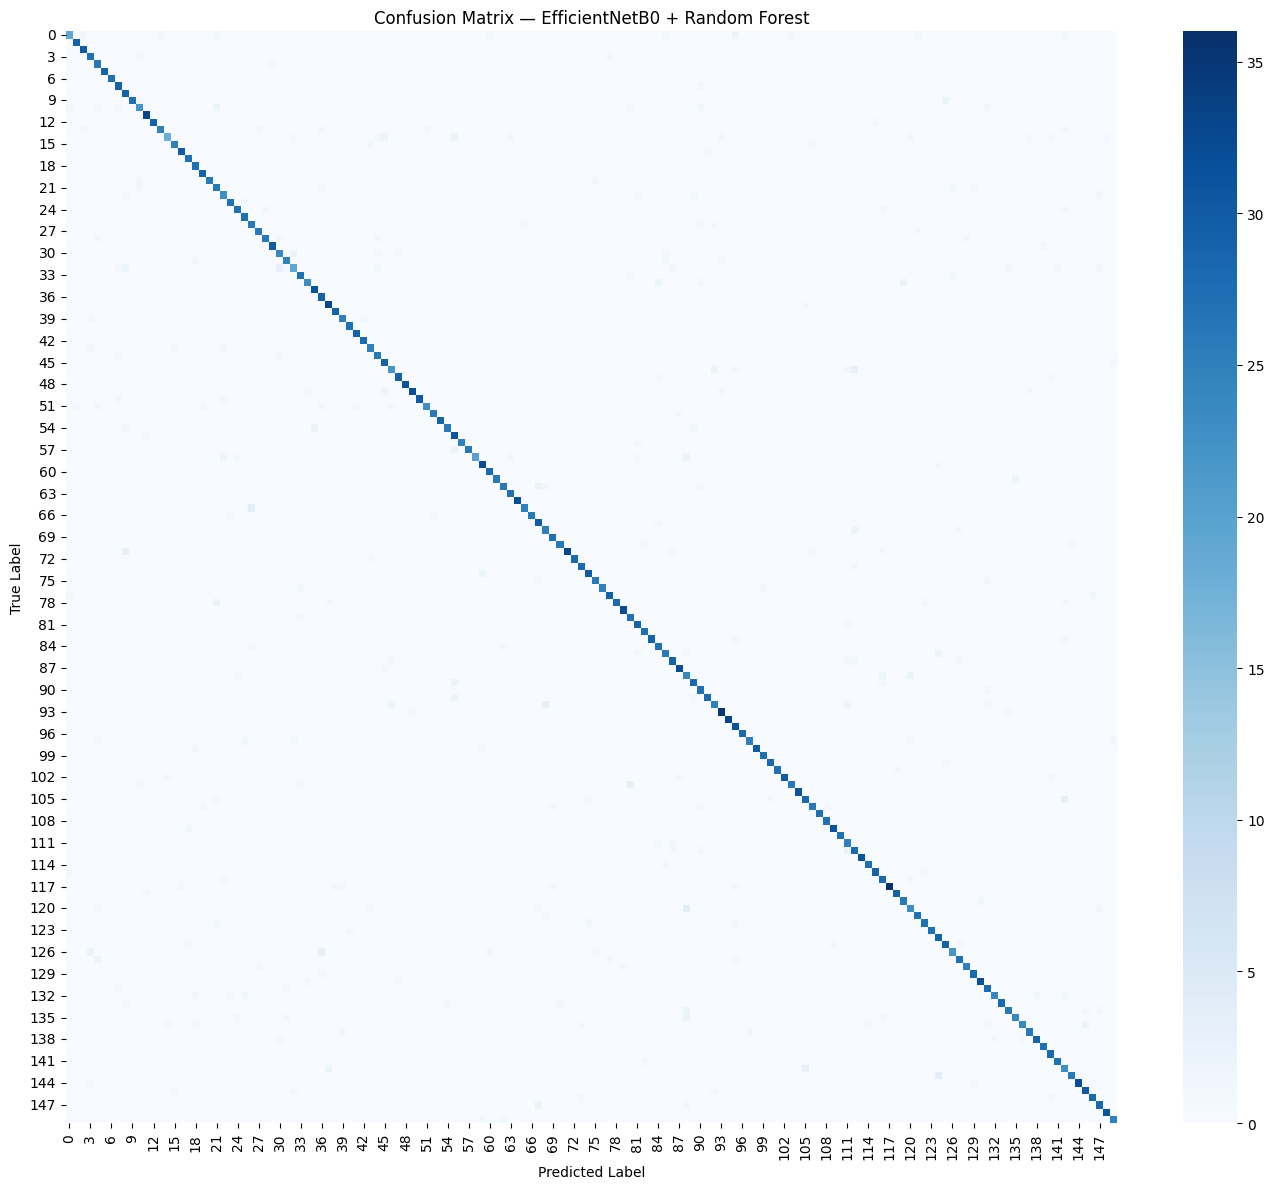

In [8]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix — EfficientNetB0 + Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [9]:

# Classification Report
class_names = list(test_gen.class_indices.keys())
print(classification_report(y_test, y_pred_test,
                            target_names=class_names,
                            zero_division=0))

                               precision    recall  f1-score   support

                ABBOTTS BOOBY       0.86      0.66      0.75        29
   ABYSSINIAN GROUND HORNBILL       0.97      1.00      0.98        29
        AFRICAN PIED HORNBILL       0.94      1.00      0.97        30
          AFRICAN PYGMY GOOSE       0.84      0.93      0.89        29
                ALPINE CHOUGH       0.79      0.96      0.87        27
              AMERICAN AVOCET       1.00      1.00      1.00        29
             AMERICAN BITTERN       1.00      1.00      1.00        27
              AMERICAN DIPPER       0.85      0.97      0.91        30
               AMERICAN PIPIT       0.78      1.00      0.88        29
              AMERICAN WIGEON       1.00      0.90      0.95        30
            ASHY STORM PETREL       0.81      0.73      0.77        30
        ASIAN GREEN BEE EATER       0.94      1.00      0.97        33
         ASIAN OPENBILL STORK       1.00      0.97      0.98        30
     

## 10. Lưu Model

In [10]:
MODEL_SAVE_PATH = '/content/drive/MyDrive/CS231/models_aug'
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
joblib.dump(rf,  os.path.join(MODEL_SAVE_PATH, 'best_rf_model.joblib'))
# joblib.dump(pca, os.path.join(MODEL_SAVE_PATH, 'pca_512_transformer.joblib'))

print('Đã lưu model vào Drive:')
print(f'  {MODEL_SAVE_PATH}best_rf_model.joblib')
# print(f'  {MODEL_SAVE_PATH}pca_512_transformer.joblib')

Đã lưu model vào Drive:
  /content/drive/MyDrive/CS231/models_augbest_rf_model.joblib


RF model sẵn sàng.
Đã chọn 10 ảnh từ tập test.

Đang khởi tạo trình biên dịch C++ (Graph Mode) cho mô hình...
Phát hiện GPU: /physical_device:GPU:0

🚀 Đang chạy max-speed benchmark trên CPU ...

🚀 Đang chạy max-speed benchmark trên GPU ...

+══════════════════════════════════════════════════════════════════════+
  [Trích xuất: CPU | Phân loại: CPU] KẾT QUẢ TỪNG ẢNH
+══════════════════════════════════════════════════════════════════════+
  #  File                         True               Pred                 Conf   Ext(ms)   RF(ms)  OK
-----------------------------------------------------------------------------------------------
  1  072.jpg                      HOUSE FINCH        HOUSE FINCH         58.0%     92.50   84.747  ✓
  2  155.jpg                      ASIAN GREEN BEE EATER ASIAN GREEN BEE EATER  60.0%     83.52   58.458  ✓
  3  058.jpg                      MILITARY MACAW     MILITARY MACAW      67.6%     87.58   68.472  ✓
  4  051.jpg                      PHAINOPEPLA       

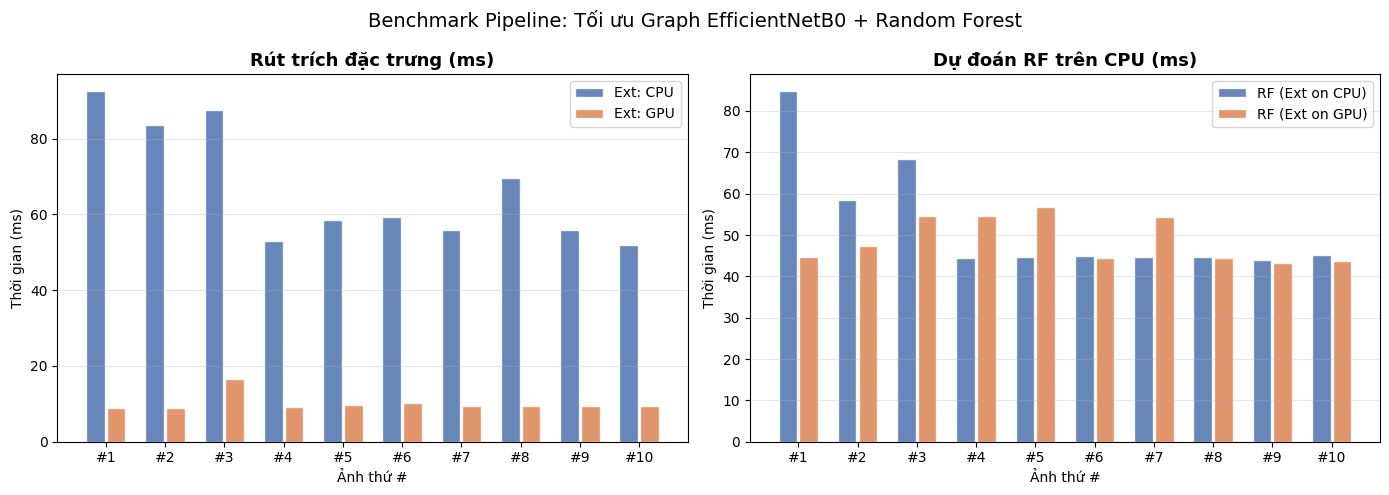


Đã lưu biểu đồ biểu diễn độ trễ: /content/benchmark_cpu_gpu_optimized.png


In [12]:
import time
import os
import joblib
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image as keras_image
import glob
import random
import matplotlib.pyplot as plt

# ══════════════════════════════════════════════════════════
# 1. CẤU HÌNH & LOAD MODEL
# ══════════════════════════════════════════════════════════
MODEL_PATH = '/content/drive/MyDrive/CS231/models_aug/best_rf_model.joblib'
N_WARMUP   = 5    # Số lần chạy mồi để TF biên dịch đồ thị
N_SAMPLE   = 10   # Số ảnh test

# Load RF Model (Giữ trong RAM để chạy trên CPU)
if 'rf' not in dir() or rf is None:
    print('Loading RF model...')
    rf = joblib.load(MODEL_PATH)
rf.verbose = 0 # TẮT log [Parallel(n_jobs=...)] cho console gọn gàng
print('RF model sẵn sàng.')

# ══════════════════════════════════════════════════════════
# 2. CHUẨN BỊ DỮ LIỆU TỪ TẬP TEST
# ══════════════════════════════════════════════════════════
all_test_images = glob.glob(os.path.join(AUG_PATH['test'], '**', '*.jpg'), recursive=True)
all_test_images += glob.glob(os.path.join(AUG_PATH['test'], '**', '*.png'), recursive=True)
all_test_images += glob.glob(os.path.join(AUG_PATH['test'], '**', '*.jpeg'), recursive=True)

random.seed(42)
sample_paths = random.sample(all_test_images, min(N_SAMPLE, len(all_test_images)))
print(f'Đã chọn {len(sample_paths)} ảnh từ tập test.')

idx_to_class = {v: k for k, v in train_gen.class_indices.items()}

# ══════════════════════════════════════════════════════════
# 3. HÀM TỐI ƯU CỦA TENSORFLOW (MAGIC HAPPENS HERE 🪄)
# ══════════════════════════════════════════════════════════
def load_image_batch(path):
    img = keras_image.load_img(path, target_size=(224, 224))
    return np.expand_dims(keras_image.img_to_array(img), axis=0)

print("\nĐang khởi tạo trình biên dịch C++ (Graph Mode) cho mô hình...")

# Bùa chú số 1: Khóa cứng toàn bộ mô hình thành Graph tĩnh trên GPU
@tf.function(reduce_retracing=True)
def fast_extract(model, image_tensor):
    return model(image_tensor, training=False)

def run_benchmark_on_device(extractor, image_paths, device_name):
    extract_times, rf_times, results = [], [], []

    # Khóa môi trường làm việc vào Device (CPU hoặc GPU)
    with tf.device(device_name):

        # ── WARMUP: Ép TF biên dịch và load trọng số lên VRAM ──
        dummy_img = load_image_batch(image_paths[0])
        dummy_tensor_cpu = tf.constant(dummy_img, dtype=tf.float32)
        dummy_tensor_device = tf.identity(dummy_tensor_cpu) # Ép đẩy lên VRAM

        for _ in range(N_WARMUP):
            _ = fast_extract(extractor, dummy_tensor_device)

        # ── BENCHMARK CHÍNH THỨC ──
        for img_path in image_paths:
            img_batch = load_image_batch(img_path)

            # a. Khởi tạo ảnh trên RAM (CPU)
            img_tensor_cpu = tf.constant(img_batch, dtype=tf.float32)

            # b. Bùa chú số 2: Đẩy ảnh lên sẵn VRAM (GPU) TRƯỚC KHI bấm giờ
            img_tensor_device = tf.identity(img_tensor_cpu)

            # =======================================================
            # BƯỚC 1: TRÍCH XUẤT ĐẶC TRƯNG (Đo thời gian tính toán thuần)
            t0 = time.perf_counter()

            feat_tensor = fast_extract(extractor, img_tensor_device)
            feat = feat_tensor.numpy()  # Ép đồng bộ và lấy vector về RAM

            t1 = time.perf_counter()
            ext_ms = (t1 - t0) * 1000
            extract_times.append(ext_ms)
            # =======================================================

            # =======================================================
            # BƯỚC 2: RANDOM FOREST DỰ ĐOÁN (Chỉ chạy trên CPU)
            t0 = time.perf_counter()

            pred_proba = rf.predict_proba(feat)

            t1 = time.perf_counter()
            rf_ms = (t1 - t0) * 1000
            rf_times.append(rf_ms)
            # =======================================================

            # Xử lý kết quả báo cáo
            pred_cls_idx = np.argmax(pred_proba[0])
            label      = idx_to_class[pred_cls_idx]
            confidence = pred_proba[0][pred_cls_idx] * 100
            true_label = os.path.basename(os.path.dirname(img_path))

            results.append({
                'file'       : os.path.basename(img_path),
                'true'       : true_label,
                'pred'       : label,
                'conf'       : confidence,
                'correct'    : true_label == label,
                'extract_ms' : ext_ms,
                'rf_ms'      : rf_ms,
            })

    return extract_times, rf_times, results

# ══════════════════════════════════════════════════════════
# 4. THỰC THI BENCHMARK
# ══════════════════════════════════════════════════════════
gpu_list = tf.config.list_physical_devices('GPU')
devices_to_test = [('/CPU:0', 'CPU')]
if gpu_list:
    devices_to_test.append(('/GPU:0', 'GPU'))
    print(f'Phát hiện GPU: {gpu_list[0].name}')
else:
    print('Không có GPU — chỉ chạy CPU.')

all_device_stats = {}

for device_path, device_label in devices_to_test:
    print(f'\n🚀 Đang chạy max-speed benchmark trên {device_label} ...')
    ext_t, rf_t, res = run_benchmark_on_device(feature_extractor, sample_paths, device_path)
    all_device_stats[device_label] = {
        'extract_times': ext_t,
        'rf_times'     : rf_t,
        'results'      : res,
    }

# ══════════════════════════════════════════════════════════
# 5. IN BÁO CÁO CHI TIẾT
# ══════════════════════════════════════════════════════════
for device_label, stats in all_device_stats.items():
    print(f'\n{"+" + "═"*70 + "+"}')
    print(f'  [Trích xuất: {device_label} | Phân loại: CPU] KẾT QUẢ TỪNG ẢNH')
    print(f'{"+" + "═"*70 + "+"}')
    hdr = f'{"#":>3}  {"File":<28} {"True":<18} {"Pred":<18} {"Conf":>6}  {"Ext(ms)":>8}  {"RF(ms)":>7}  OK'
    print(hdr)
    print('-' * 95)
    for i, r in enumerate(stats['results'], 1):
        ok = '✓' if r['correct'] else '✗'
        print(f"{i:>3}  {r['file']:<28} {r['true']:<18} {r['pred']:<18} "
              f"{r['conf']:>5.1f}%  {r['extract_ms']:>8.2f}  {r['rf_ms']:>7.3f}  {ok}")

# ══════════════════════════════════════════════════════════
# 6. IN THỐNG KÊ TỔNG QUAN
# ══════════════════════════════════════════════════════════
print(f'\n{"+" + "═"*55 + "+"}')
print('  THỐNG KÊ HIỆU NĂNG (TỐI ƯU HÓA GRAPH)')
print(f'{"+" + "═"*55 + "+"}')

for device_label, stats in all_device_stats.items():
    et = np.array(stats['extract_times'])
    rt = np.array(stats['rf_times'])
    n_correct = sum(r['correct'] for r in stats['results'])

    print(f'\n  ┌─ Hệ thống: Trích xuất ({device_label}) + Phân loại (CPU) ───')
    print(f'  │  Rút trích đặc trưng (EfficientNetB0 - Tối ưu)')
    print(f'  │    Mean ± Std : {et.mean():.2f} ± {et.std():.2f} ms')
    print(f'  │    Min / Max  : {et.min():.2f} / {et.max():.2f} ms')
    print(f'  │')
    print(f'  │  Dự đoán Random Forest (Chỉ chạy trên CPU)')
    print(f'  │    Mean ± Std : {rt.mean():.3f} ± {rt.std():.3f} ms')
    print(f'  │    Min / Max  : {rt.min():.3f} / {rt.max():.3f} ms')
    print(f'  │')
    print(f'  │  Tổng pipeline (mean)  : {(et + rt).mean():.2f} ms/ảnh')
    print(f'  │  Độ chính xác 10 ảnh   : {n_correct}/{N_SAMPLE} ({n_correct/N_SAMPLE*100:.0f}%)')
    print(f'  └────────────────────────────────────────────────')

# ══════════════════════════════════════════════════════════
# 7. VẼ BIỂU ĐỒ TRỰC QUAN
# ══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'CPU': '#4C72B0', 'GPU': '#DD8452'}
x = np.arange(N_SAMPLE)
width = 0.35 / max(len(all_device_stats), 1)

for ax_idx, (title, key) in enumerate([('Rút trích đặc trưng (ms)', 'extract_times'),
                                       ('Dự đoán RF trên CPU (ms)', 'rf_times')]):
    ax = axes[ax_idx]
    for d_idx, (device_label, stats) in enumerate(all_device_stats.items()):
        offset = (d_idx - len(all_device_stats)/2 + 0.5) * width * 2

        legend_label = f"Ext: {device_label}" if key == 'extract_times' else f"RF (Ext on {device_label})"

        bars = ax.bar(x + offset, stats[key],
                      width=width*1.8,
                      label=legend_label,
                      color=colors.get(device_label, '#55A868'),
                      alpha=0.85, edgecolor='white')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Ảnh thứ #')
    ax.set_ylabel('Thời gian (ms)')
    ax.set_xticks(x)
    ax.set_xticklabels([f'#{i+1}' for i in x])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Benchmark Pipeline: Tối ưu Graph EfficientNetB0 + Random Forest', fontsize=14)
plt.tight_layout()
plt.savefig('/content/benchmark_cpu_gpu_optimized.png', dpi=150)
plt.show()
print('\nĐã lưu biểu đồ biểu diễn độ trễ: /content/benchmark_cpu_gpu_optimized.png')